# **Diwali Sales Ananlysis**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

### **Importing Raw Data**

In [5]:
df=pd.read_csv('Diwali Sales Data.csv',encoding='unicode_escape') #encoding is ues to avoid error

In [6]:
df.shape

(11251, 15)

In [7]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
#Drop Unrelated/blank Column
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [10]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [13]:
df['Amount']=df['Amount'].astype('int')


In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [16]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


## **Exploratory Data Analysis**

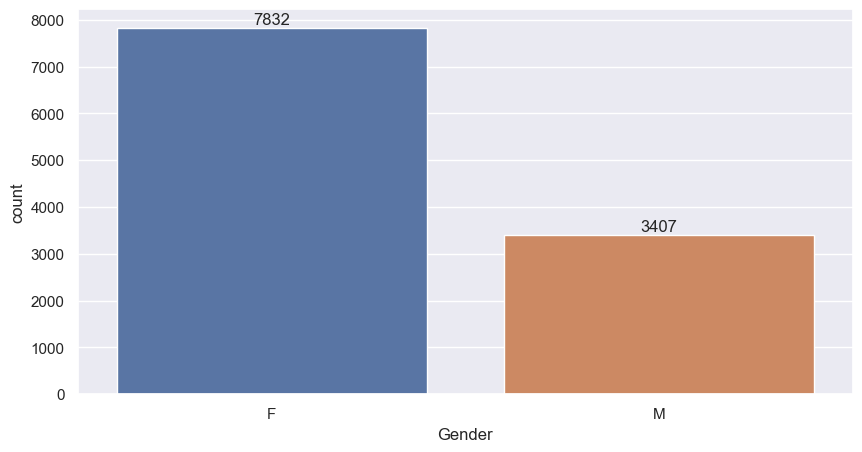

In [102]:
# Countplot on Gender
ax=sns.countplot(x='Gender',data=df,hue='Gender')
sns.set(rc={'figure.figsize':(5,2)})


for bars in ax.containers:
    ax.bar_label(bars)

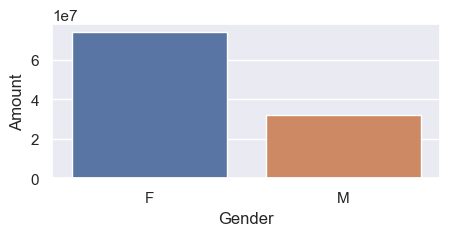

In [103]:
sales_gen=df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(x='Gender',y='Amount',data=sales_gen,hue='Gender')
plt.show()

                     

### **From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men**

### Age 

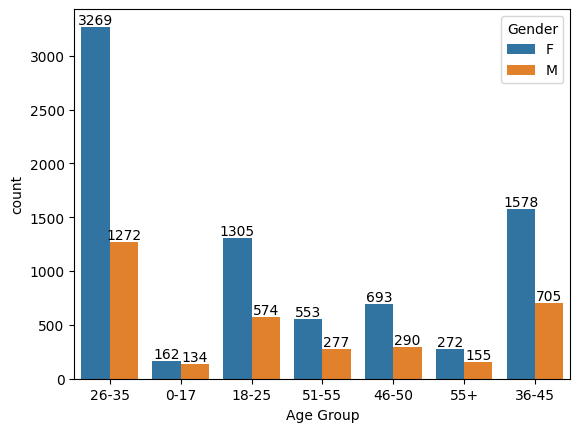

In [22]:
#Total Amount vs Age Group

ax=sns.countplot(data=df,x='Age Group',hue='Gender')

for bars in ax.containers:
    ax.bar_label(bars)

### **From above Graph we can see that most of the buyers are of age group between 26-35 Years** 

### *State*

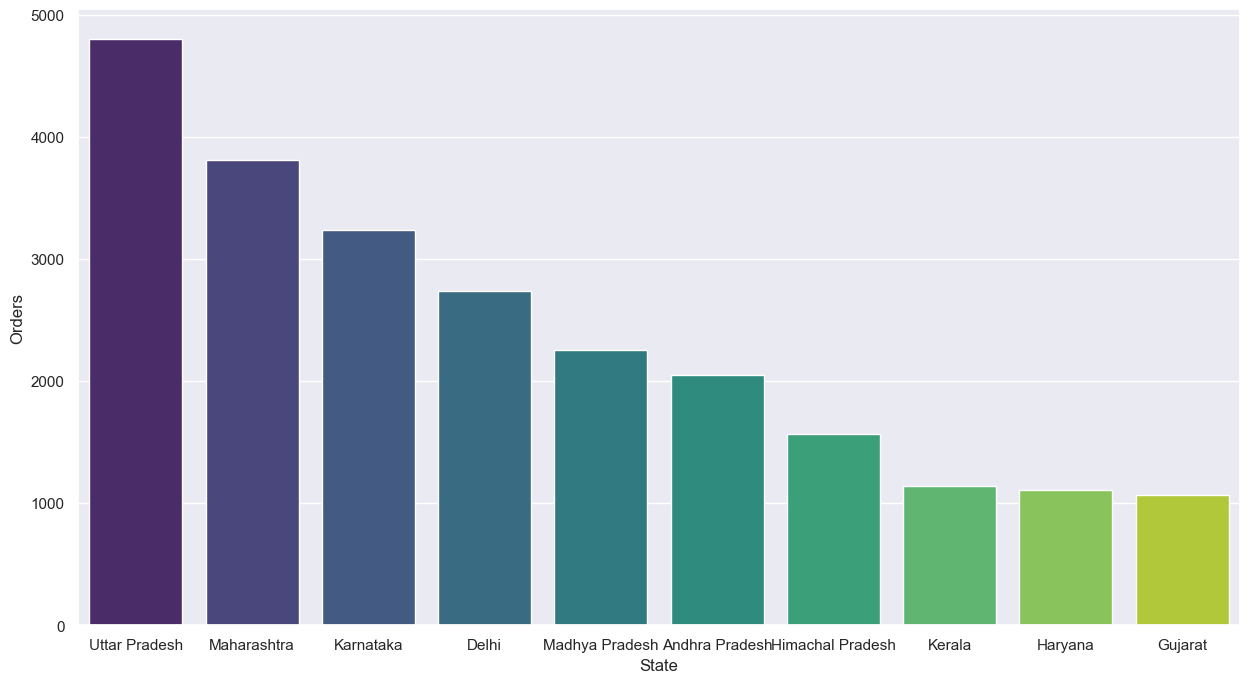

In [104]:
# Total Number of Orders from Top 10 States

sales_data=df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,8)})
sns.barplot(data=sales_data, x='State',y='Orders',hue='State',palette='viridis',legend=False)
plt.show()

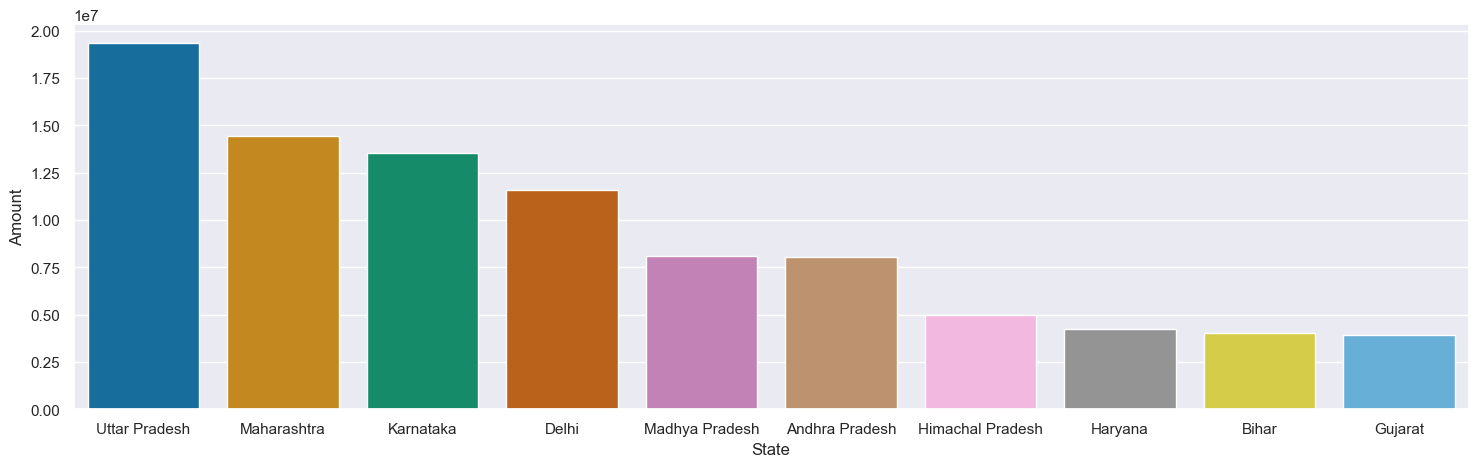

In [40]:
# Total Amount/Sales from Top 10 States

sales_state=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)

sns.set(rc={'figure.figsize':(18,5)})
sns.barplot(data=sales_state,x='State',y='Amount',hue='State',palette='colorblind',legend=False)
plt.show()

#### **From above graphs we can see that unexpectedly most of the orders are from Uttar Pradesh,Maharashtra and Karnataka respectively but total amount is from UP,Karnataka and Then Maharashtra**

### **Maritial Status** 

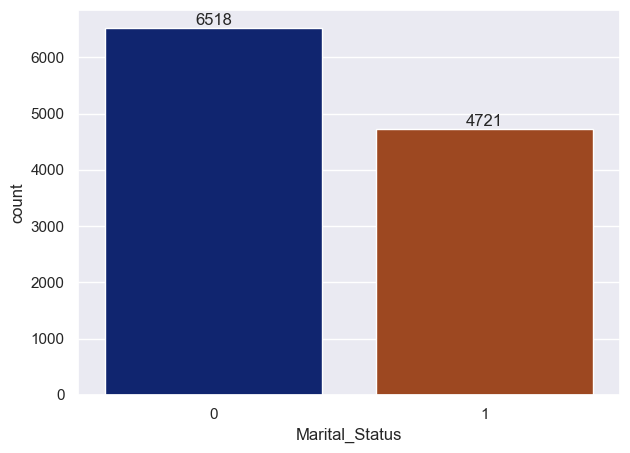

In [51]:
ax=sns.countplot(data=df,x='Marital_Status',palette='dark',legend=False,hue='Marital_Status')
sns.set(rc={'figure.figsize':(2,2)})
for bars in ax.containers:
    ax.bar_label(bars)

#### **Sales on the basis of Maritial status and Gender**

<Axes: xlabel='Marital_Status', ylabel='Amount'>

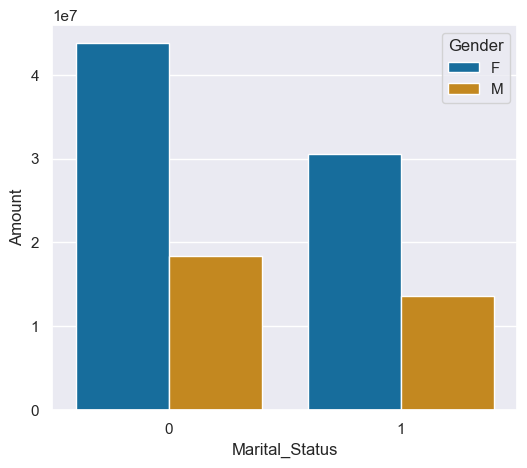

In [57]:
sales_state=df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data=sales_state,x='Marital_Status',y='Amount',hue='Gender',palette='colorblind')

#### **From above Graph we can see that most of the buyers are married(Women) and they have high purchase power**

#### **Occupation**

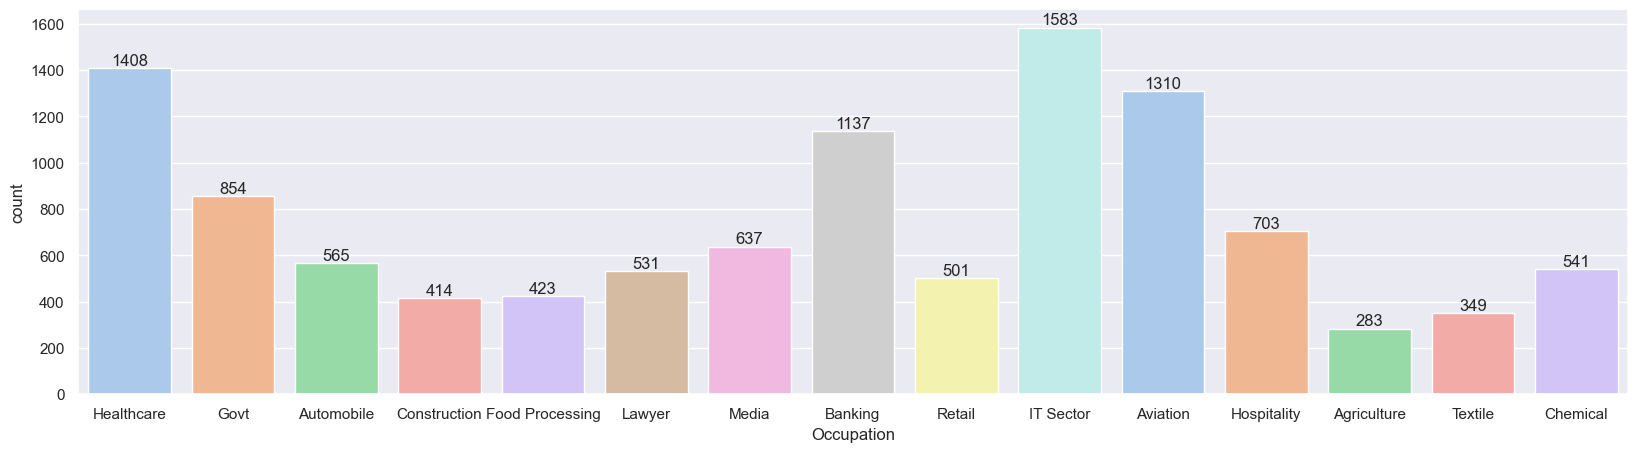

In [63]:
sns.set(rc={'figure.figsize':(20,5)})

ax=sns.countplot(data=df,x='Occupation',palette='pastel',legend=False,hue='Occupation')
                 

for bars in ax.containers:
    ax.bar_label(bars)
            

#### **From the above Graph we can see that Top 2 Buyers are from IT Sector and Healthcare**

#### **Which sector have More Purchasing Power**

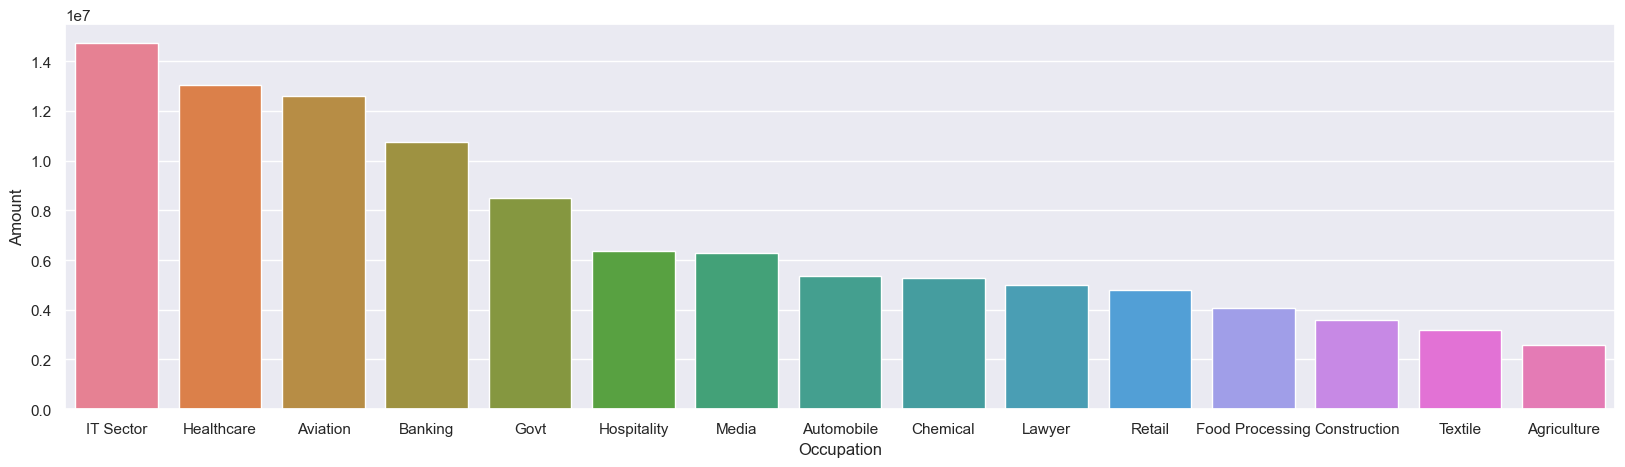

In [66]:
sales_state=df.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_state,x='Occupation',y='Amount',hue='Occupation')
plt.show()

#### **From the above Graph we can see that most of the buyers are working in IT,Aviation and Healthcare Sector**

#### **Product Category**

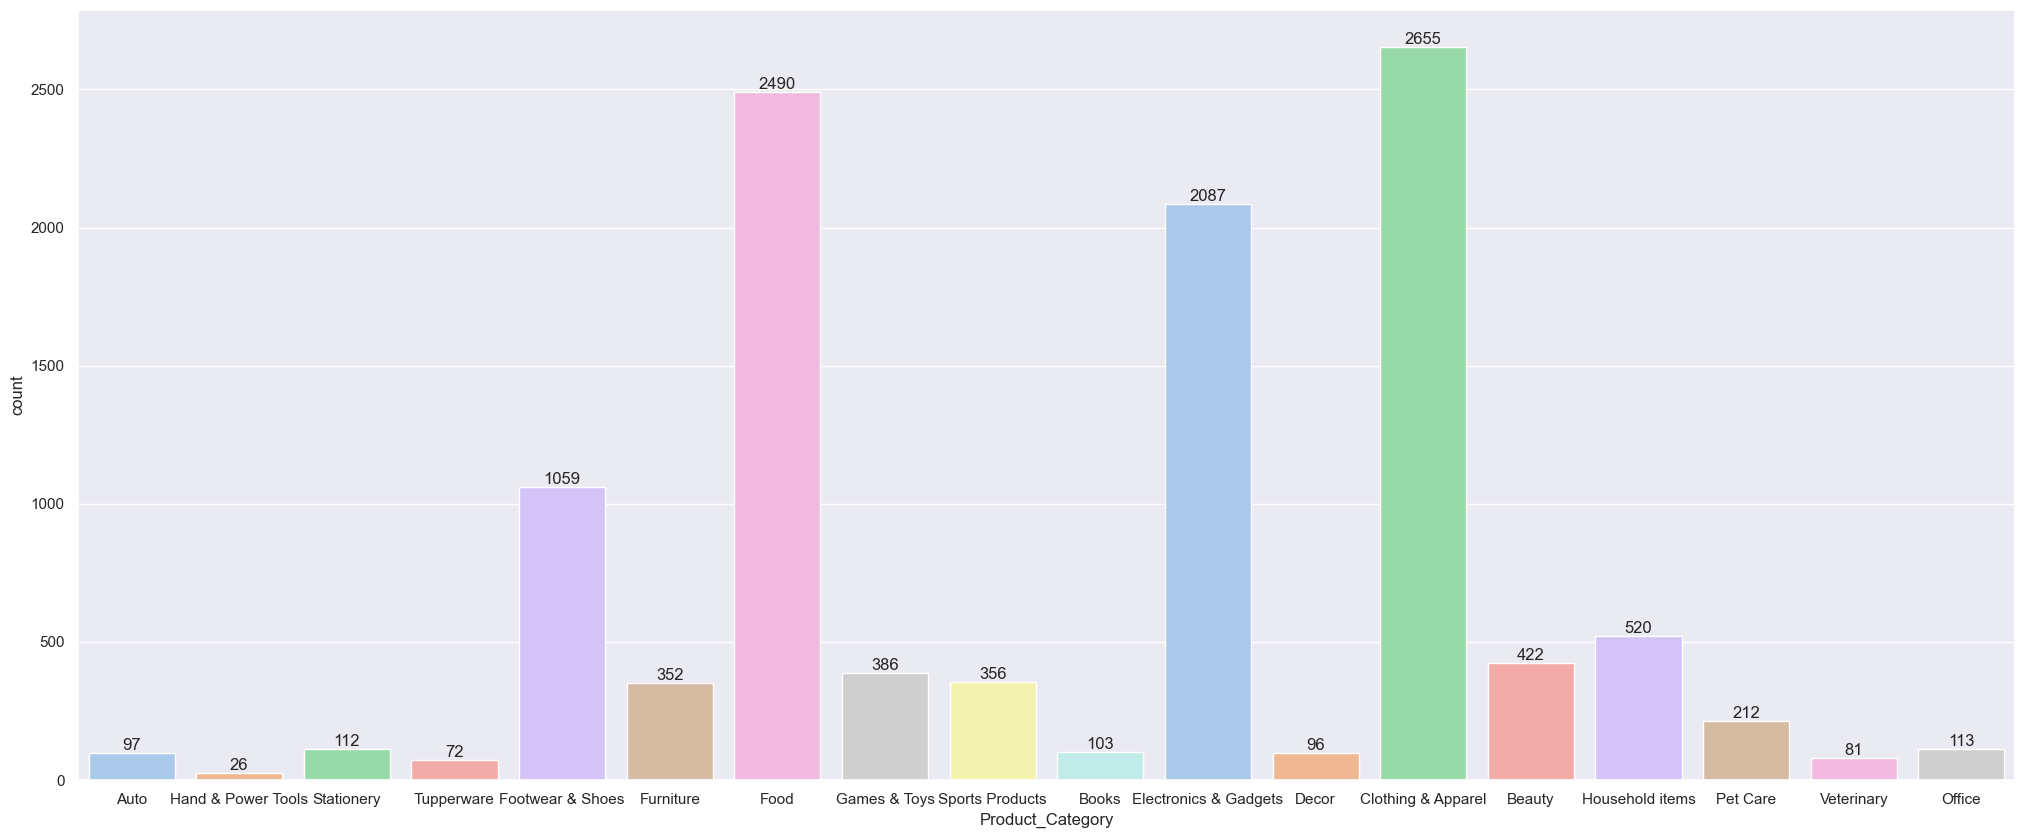

In [95]:
sns.set(rc={'figure.figsize':(25,10)})
ax=sns.countplot(data=df,x='Product_Category',palette='pastel',legend=False,hue='Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

#### **Highest Sale is of Clothing, Food and then Electronics**

##### **Highest Amount Spend According to Product**

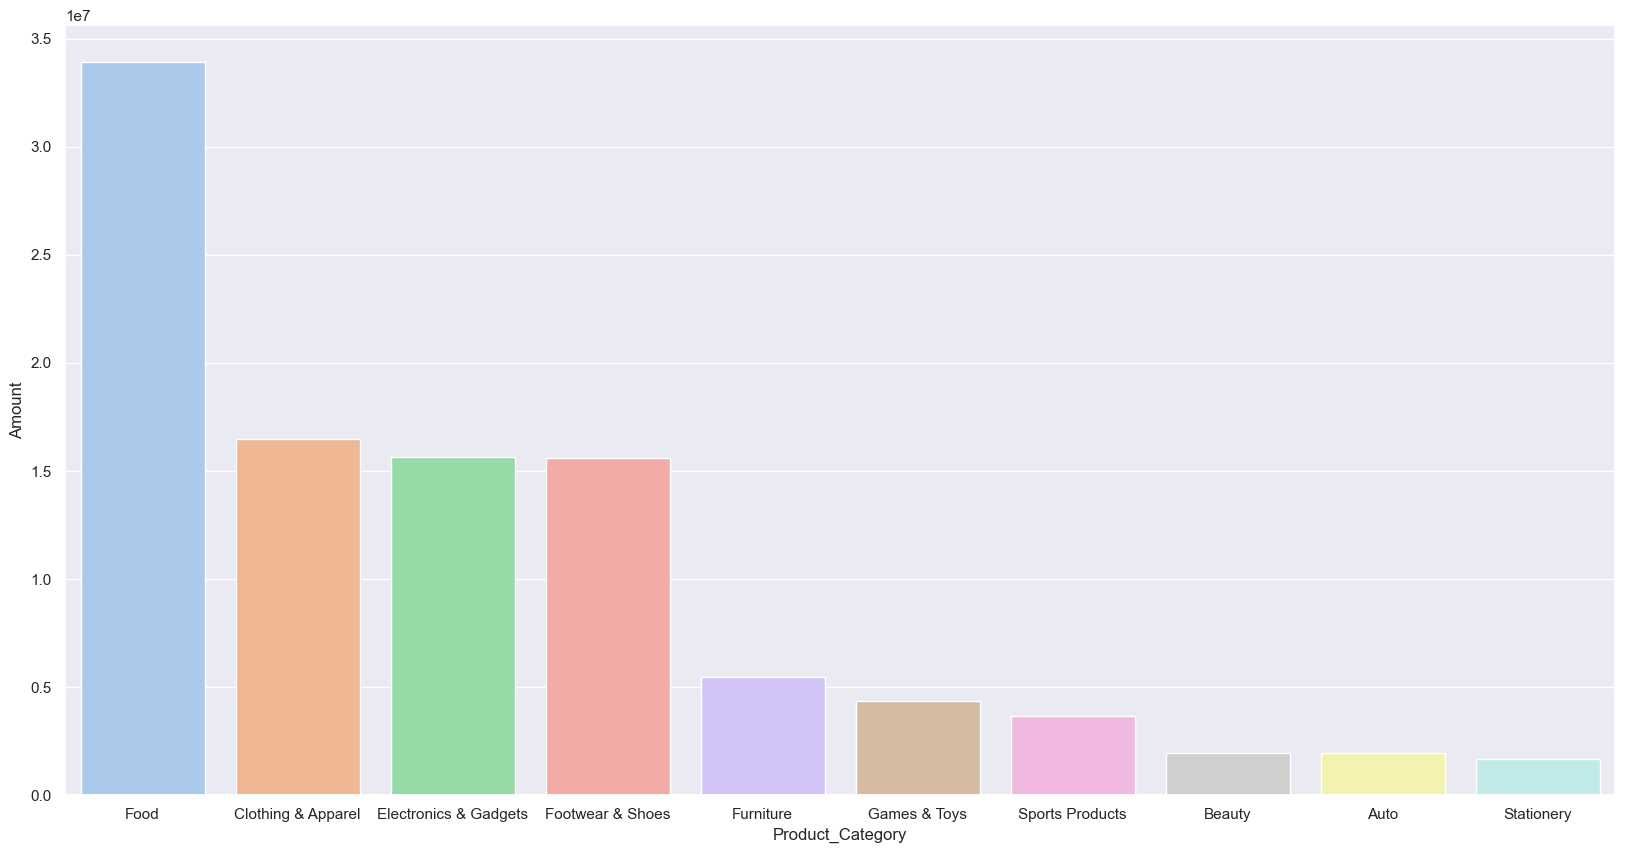

In [93]:
sales_state=df.groupby(['Product_Category'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(20,10)})
sns.barplot(data=sales_state,x='Product_Category',y='Amount',palette='pastel',legend=False,hue='Product_Category')
plt.show()


#### **But Highest Money is spend on Food then Clothing ,Electronics**

#### **Top 10 Products**

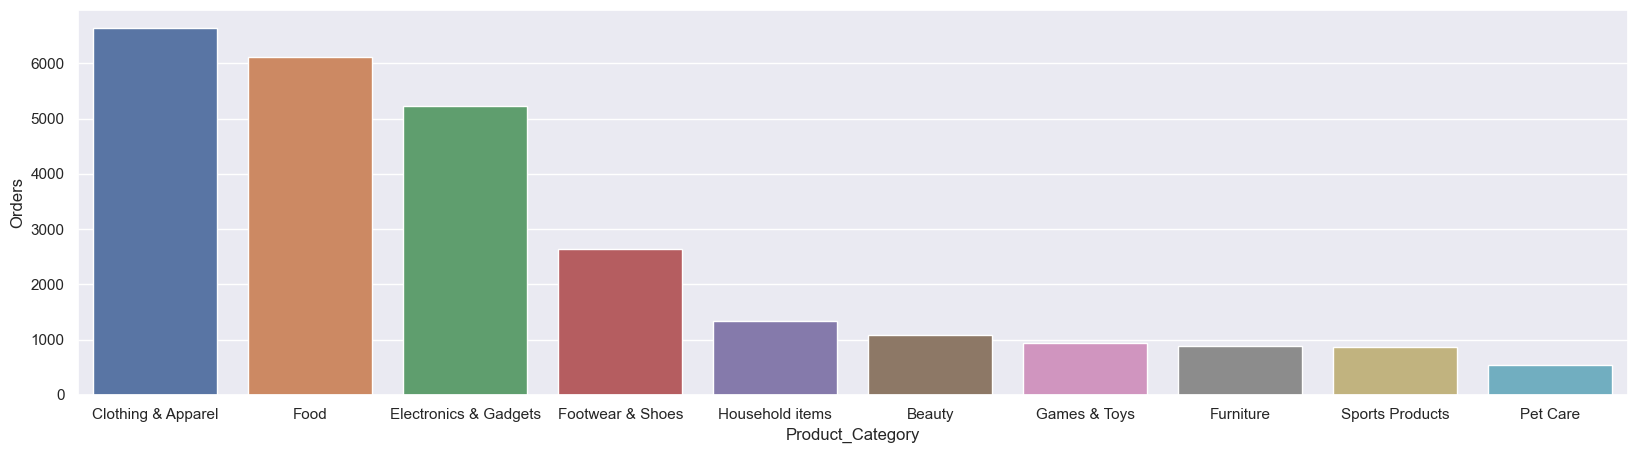

In [98]:
sales_state=df.groupby(['Product_Category'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_state,x='Product_Category',y='Orders',hue='Product_Category')
plt.show()